## **Behavior between AR and MA**

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [12]:
# Configuration
np.random.seed(42)
n = 200
phi = 0.6   # AR parameter
theta = 0.6 # MA parameter

# Generate White Noise (Epsilon)
epsilon = np.random.normal(0, 1, n)

In [13]:
# --- 1. Simulate AR(1): X_t = 0.6 * X_{t-1} + e_t ---
ar1 = np.zeros(n)
ar1[0] = epsilon[0]
for t in range(1, n):
    ar1[t] = phi * ar1[t-1] + epsilon[t]

In [14]:
# --- 2. Simulate MA(1): X_t = e_t + 0.6 * e_{t-1} ---
ma1 = np.zeros(n)
ma1[0] = epsilon[0]
for t in range(1, n):
    ma1[t] = epsilon[t] + theta * epsilon[t-1]

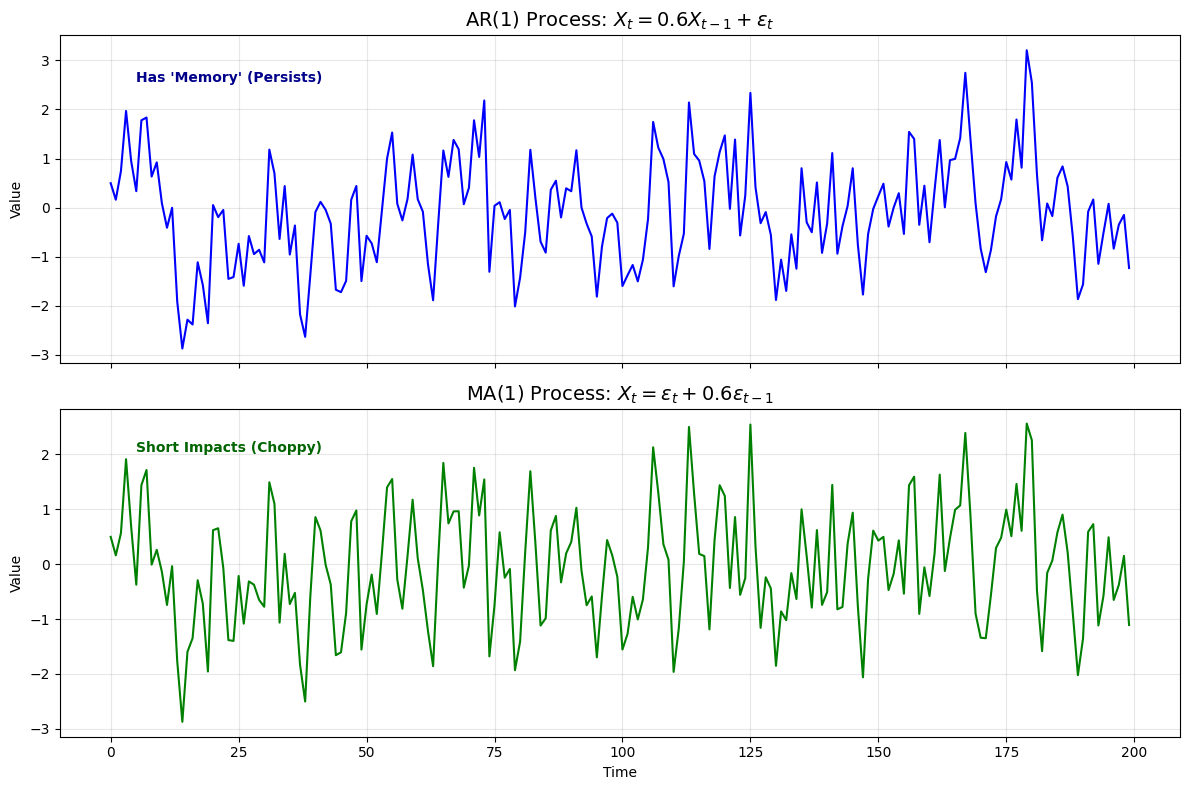

In [15]:
# --- 3. Plotting ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# AR(1) Plot
ax1.plot(ar1, color='blue', linestyle='-', linewidth=1.5)
ax1.set_title(f'AR(1) Process: $X_t = {phi} X_{{t-1}} + \epsilon_t$', fontsize=14)
ax1.set_ylabel('Value')
ax1.grid(True, alpha=0.3)
ax1.text(5, max(ar1)*0.8, "Has 'Memory' (Persists)", color='darkblue', fontweight='bold')

# MA(1) Plot
ax2.plot(ma1, color='green', linestyle='-', linewidth=1.5)
ax2.set_title(f'MA(1) Process: $X_t = \epsilon_t + {theta} \epsilon_{{t-1}}$', fontsize=14)
ax2.set_xlabel('Time')
ax2.set_ylabel('Value')
ax2.grid(True, alpha=0.3)
ax2.text(5, max(ma1)*0.8, "Short Impacts (Choppy)", color='darkgreen', fontweight='bold')

plt.tight_layout()
plt.show()

# Interpretation of Behavior: AR(1) vs MA(1)

When you run the code, you will notice clear behavioral differences in the graphs, even though both models use the same coefficient (**0.6**). These differences come from the way each model handles memory.

---

## 1. **AR(1) Process (Auto-Regressive)**

### **Equation**
\[
X_t = 0.6X_{t-1} + \varepsilon_t
\]

### **Visual Behavior**
The graph appears **wavier**, smoother, and more persistent over time.

### **Why This Happens**
- AR models have **long-term memory**.
- A large value of \(X_{t-1}\) strongly influences \(X_t\) because 60% of the previous value is carried forward.
- A shock at time *t* affects:
  - \(X_t\)
  - \(X_{t+1}\)
  - \(X_{t+2}\)
  - and continues with slowly decaying influence.

This produces the **"ripple effect"**, making the series look persistent.

---

## 2. **MA(1) Process (Moving Average)**

### **Equation**
\[
X_t = \varepsilon_t + 0.6\varepsilon_{t-1}
\]

### **Visual Behavior**
The graph looks **choppier**, more **spiky**, and returns to its mean (0) much more quickly.

### **Why This Happens**
- MA models have **short-term memory**.
- \(X_t\) depends ONLY on:
  - the current shock \( \varepsilon_t \)
  - one past shock \( \varepsilon_{t-1} \)
- A shock at time *t* influences:
  - \(X_t\)
  - \(X_{t+1}\)
  - By \(X_{t+2}\), the shock is **completely forgotten**.

This causes the series to look less smooth and more abrupt in behavior.

---

### **Summary Table**

| Model | Memory | Graph Style | Shock Effect Duration |
|-------|--------|-------------|------------------------|
| **AR(1)** | Long-term | Smooth, wavy | Slowly decays over many steps |
| **MA(1)** | Short-term | Choppy, spiky | Lasts only 1–2 steps |

---
